<a href="https://colab.research.google.com/github/Aarjav8055/ML-LAB/blob/main/LAB11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
                       text  label
0  I love machine learning      1
1   This is a great course      1
2      I hate bugs in code      0
3         This is very bad      0
4           I enjoy coding      1
5      Terrible experience      0
6             Amazing work      1
7       Worst project ever      0
8              I like this      1
9          Not good at all      0

Accuracy: 0.3333333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3


Actual: [0, 0, 1]
Predicted: [np.int64(1), np.int64(1), np.int64(1)]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


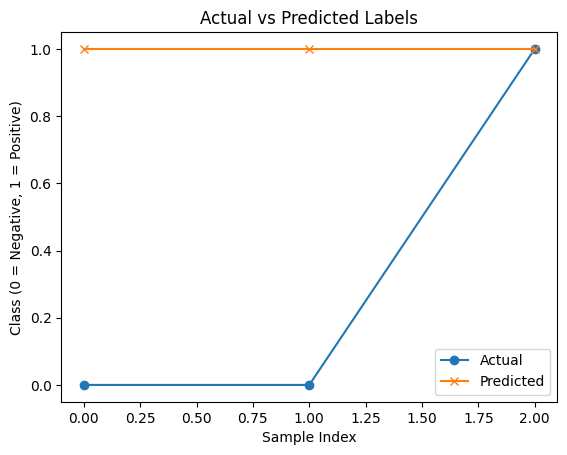

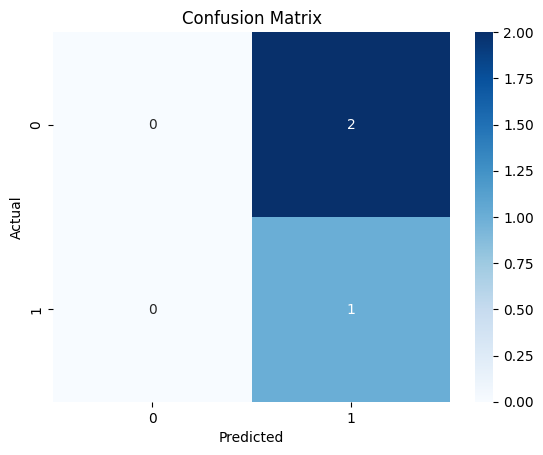


✅ Lab 11 executed successfully with graphs


In [4]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================
# 2. Create Dataset (Balanced)
# =========================================
data = {
    "text": [
        "I love machine learning",
        "This is a great course",
        "I hate bugs in code",
        "This is very bad",
        "I enjoy coding",
        "Terrible experience",
        "Amazing work",
        "Worst project ever",
        "I like this",
        "Not good at all"
    ],
    "label": [1,1,0,0,1,0,1,0,1,0]
}

df = pd.DataFrame(data)

print("Dataset:\n", df)

# =========================================
# 3. Text Vectorization
# =========================================
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["text"])
y = df["label"]

# =========================================
# 4. Train-Test Split (IMPORTANT FIX)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# =========================================
# 5. Model Training
# =========================================
model = MultinomialNB()
model.fit(X_train, y_train)

# =========================================
# 6. Prediction
# =========================================
y_pred = model.predict(X_test)

# =========================================
# 7. Evaluation
# =========================================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nActual:", list(y_test))
print("Predicted:", list(y_pred))

# =========================================
# 8. Graph 1: Actual vs Predicted
# =========================================
plt.figure()

plt.plot(list(y_test), marker='o', label='Actual')
plt.plot(list(y_pred), marker='x', label='Predicted')

plt.title("Actual vs Predicted Labels")
plt.xlabel("Sample Index")
plt.ylabel("Class (0 = Negative, 1 = Positive)")
plt.legend()
plt.show()

# =========================================
# 9. Graph 2: Confusion Matrix
# =========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# DONE
# =========================================
print("\n✅ Lab 11 executed successfully with graphs")